In [289]:
import torch
from torch import nn
from torch.utils.data import random_split, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import os
import pandas as pd
from torch.utils.data import Dataset
# import sklearn
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda
import matplotlib.colors as mcolors

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold


import matplotlib.pyplot as plt
import wandb

import os
import datetime

In [ ]:
# Open questions

# How can I place a hard constrain that Mtot,f<= Mtot, i and M1f<=Mtot,f
# What is the best way to evaluate model perfomance? The absolute error is based on the ratio of masses. 
# Do I have to startify the data?
# I need to do parameter search: lr, epoch 
# Q: why do the errors look so bad but the plots look good?

In [290]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

In [291]:
print(device)

mps


In [292]:
#This is in place to fix all variables so I can gauge how effective changes are 
torch.manual_seed(42)
np.random.seed(42)

# Make training deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


#### **Put data into a database**

In [293]:

class CustomDataset(Dataset):
    def __init__(self, labels, data, dir, transform=None, target_transform=None):
        self.labels = labels
        self.data = data
        self.dir = dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        
        data = self.data[idx]
        label = self.labels[idx]

        data = torch.from_numpy(data).type(torch.float)
        label = torch.tensor(label)

        if self.transform:
            data = self.transform(data)
        if self.target_transform:
            label = self.target_transform(label)
                            
        return data, label

In [294]:
#--- Create the dataset ---# 

# 0:Met[Zsun],1:Age[Gyr],2:Rp[Rsun],3:Vinf[km/s],4:Mass1_i[MSUN],5:Mass2_i[Msun],6:R1[Rsun],7:R2[Rsun],8:Label,9:Mass1_f[MSUN],10:Mass2_f[MSUN],11:Sigma
# data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot19f.csv'
# data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot22f.csv'
data_dir = '../../data_n10k_splot22f.csv'

data_loaded  = np.loadtxt(data_dir, delimiter=',', dtype=float, skiprows = 1)

# Selecting only the columns I want to have the format: 
# 0:Met[Zsun],1:Age[Gyr],2:Rp[Rsun],3:Vinf[km/s],4:Mass1_i[MSUN],5:Mass2_i[Msun],6:R1[Rsun],7:R2[Rsun],8:Label,9:Mass1_f[MSUN],10:Mass2_f[MSUN],11:Sigma
data = data_loaded[:, [0, 1, 2, 3, 4, 5, 8]]
initial_masses = data_loaded[:, [4, 5]]
final_masses = data_loaded[:, [9, 10]]

#Re-assing final masses for merger cases to be all in mass1, otherwise there's a lot of confusinon 
merger_mask = data_loaded[:, 8] == 1
swap_rows = merger_mask & (final_masses[:, 0] == 0) & (final_masses[:, 1] > 0)
final_masses[swap_rows, 0], final_masses[swap_rows, 1] = (final_masses[swap_rows, 1], final_masses[swap_rows, 0])


# Now create the regression dataset as [Mtot,f / Mtot,i , M1,f / Mtot, f]
y_data_reg = np.array([(final_masses[:,0] + final_masses[:,1]) / (initial_masses[:,0] + initial_masses[:,1]) , final_masses[:,0] / (final_masses[:,0] + final_masses[:,1])]).T

# Reassign M1,f / Mtot,f = 0 to cases where both stars are destroyed (and Mtot,f=0, leading to infs)
destroyed_mask = data_loaded[:, 8] == 0
y_data_reg[destroyed_mask,1] = 0.

#Feature transform: log the x-data
x_data = data[:, 1:-1] # don't need met or labels
x_data[:, 0] = np.log10(x_data[:, 0]) # log ages
x_data[:, 2] = np.log10(x_data[:, 2]) # log vinfs
print(np.shape(x_data), np.shape(y_data_reg))

#Save the original input for later 
x_data_og = x_data

#Split into Training + Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(x_data, y_data_reg, test_size=0.30,  random_state=42)

# Split the temporary into validation and testing sets 
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(np.shape(X_train), np.shape(X_val), np.shape(X_test))

# Standard Normalize the data 
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

y_train_mean = y_train.mean(axis=0)
y_train_std = y_train.std(axis=0)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std  # apply train stats
X_val = (X_val - train_mean) / train_std  # apply train stats

y_train = (y_train - y_train_mean) / y_train_std
y_test = (y_test - y_train_mean) / y_train_std  # apply train stats
y_val = (y_val - y_train_mean) / y_train_std  # apply train stats

# Create separate datasets for train and test
train_dataset = CustomDataset(dir=data_dir, labels = y_train, data = X_train, transform=None, target_transform = None)
val_dataset = CustomDataset(dir=data_dir, labels = y_val, data = X_val, transform=None, target_transform = None)
test_dataset = CustomDataset(dir=data_dir, labels = y_test, data = X_test, transform=None, target_transform = None)

#Take this out for final iteration, it is here to make sure data is shuffled the same each time
g = torch.Generator()
g.manual_seed(42)

train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True, generator=g)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False, generator=g)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False, generator=g)


for batch_data, (batch_labels) in train_dataloader:

    print("Batch data shape:", batch_data.shape)   # Correct way to check shape
    print("Batch labels shape:", batch_labels.shape)
    print("Labels dtype:", batch_labels.dtype)


(21473, 5) (21473, 2)
(15031, 5) (3221, 5) (3221, 5)
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 2])
Labels dtype: torch.float64
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 2])
Labels dtype: torch.float64
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 2])
Labels dtype: torch.float64
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 2])
Labels dtype: torch.float64
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 2])
Labels dtype: torch.float64
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 2])
Labels dtype: torch.float64
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 2])
Labels dtype: torch.float64
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 2])
Labels dtype: torch.float64
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 2])
Lab

/var/folders/4h/5kpc_p3153q1gx8btc9x_3mc0000gn/T/ipykernel_99013/889116569.py:23: RuntimeWarning: invalid value encountered in divide
  y_data_reg = np.array([(final_masses[:,0] + final_masses[:,1]) / (initial_masses[:,0] + initial_masses[:,1]) , final_masses[:,0] / (final_masses[:,0] + final_masses[:,1])]).T


### **Build Neural Network**

In [295]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # Shared layers
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(5, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [329]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model = model.to(device)
    model.train()

    train_loss, mean_absolute_error = 0, 0
    y_true = [] # Store labels for balanced accuracy
    y_pred = []  # Store labels for balanced accuracy

    for X, y in dataloader:
        X = X.to(device, dtype=torch.float32)
        y = y.to(device, dtype=torch.float32)

        # Compute prediction error
        pred = model(X)

        # Calculate overall loss
        loss = loss_fn(pred, y)

        train_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store predictions and true labels
        y_true.append(y.detach().cpu().numpy())  # Convert tensors to NumPy
        y_pred.append(pred.detach().cpu().numpy())

    train_loss /= num_batches
    
    # stack into (N, 2) arrays
    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    # assume y_true and y_pred are torch tensors
    errors = np.abs(y_pred - y_true) 

    mean_absolute_error = np.mean(errors, axis = 0) 

    # Log metrics to wandb.
    run.log({"train_loss": train_loss, "train_abs_error_Mtotf_Mtoti": mean_absolute_error[0], "train_abs_error_M1f_Mtotf": mean_absolute_error[1]})

def test(dataloader, model, loss_fn, train_mean, train_std, y_train_mean, y_train_std):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model = model.to(device)
    model.eval()
    val_loss, mean_absolute_error = 0, 0
    y_true = []
    y_pred = []
    initial_total_masses = []
    true_mass1 = []
    true_mass2 = []
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device, dtype=torch.float32)
            y = y.to(device, dtype=torch.float32)

            pred = model(X)
            val_loss += loss_fn(pred, y).item()            

            # Store predictions and true labels
            y_true.append(y.detach().cpu().numpy())  # Convert tensors to NumPy
            y_pred.append(pred.detach().cpu().numpy())

            # Get initial (unnormalized masses)
            mass1 = X[:, 3].detach().cpu().numpy() * train_std[3] + train_mean[3]
            mass2 = X[:, 4].detach().cpu().numpy() * train_std[4] + train_mean[4]
            initial_total_masses.append(mass1 + mass2)
            true_mass1.append(mass1)
            true_mass2.append(mass2)

    val_loss /= num_batches

    # Combine 
    initial_total_masses = np.concatenate(initial_total_masses)
    true_mass1 = np.concatenate(true_mass1)
    true_mass2 = np.concatenate(true_mass2)


    #-- Error metric 1: Absolute Errors in the mass ratios 
    y_true = np.vstack(y_true) # stack into (N, 2) arrays
    y_pred = np.vstack(y_pred) 
    mean_absolute_error = np.mean(np.abs(y_pred - y_true) , axis = 0)

    #-- Error metric 2: Absolute Errors in Mass 1 
    unnormalized_y0 = ( y_pred[:,0] * y_train_std[0] + y_train_mean[0]) * initial_total_masses # Convert from Mtot,f/Mtot,i to Mtot,f 
    print(initial_total_masses)
    unnormalized_y1 = (y_pred[:,1] * y_train_std[1] + y_train_mean[1]) * unnormalized_y0 # Convert from M1,f/Mtot,f to M1,f 
    predicted_mass1 = unnormalized_y1
    predicted_mass2 = unnormalized_y0 - unnormalized_y1

    mean_rel_error_m1 = np.mean(np.abs(predicted_mass1 - true_mass1)/ true_mass1) 
    mean_rel_error_m2 = np.mean(np.abs(predicted_mass2 - true_mass2)/ true_mass2) 
    
    print(predicted_mass1)
    print(true_mass1)


    print("initial_total_mass:", initial_total_masses[:5])
    print("predicted ratio (denorm):", y_pred[:5,0] * y_train_std[0] + y_train_mean[0])
    print("reconstructed Mtot,f:", unnormalized_y0[:5])

    return val_loss, mean_absolute_error, mean_rel_error_m1, mean_rel_error_m2, predicted_mass1, true_mass1


In [297]:
# Get today's date as string
date_str = datetime.datetime.now().strftime("%m%d")

# Safety stop in Jupyter
wandbname = input("Name for run: ")

if len(wandbname) == 0:
    raise RuntimeError("Stopped — you didn’t provide name for run.")
    

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="elena-gonzalez-northwestern-university",
    # Set the wandb project where this run will be logged.
    project= "ML_SPH_NN",
    name= wandbname,
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 'cosine_annealing',
        "architecture": "Regression_NN",
        "dataset": "data_n10k_splot22f.csv",
        "epochs": 1000,
        "width": 521_256_128, 
        "layers": 3,
        "batch_size": 512,
        "labels":2
    },
)

run_id = wandb.run.id  
model_name = f"model_{date_str}_{run_id}"
print(model_name)

model_0911_85f1ca33


In [298]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.utils.class_weight import compute_class_weight

# Set Hyper-parameters 
epochs = 1000

# Initialize list for storing validation loss for plotting
val_loss_history = []  # Store per-fold validation losses
lrs = []  # Store per-fold validation learning rates

best_val_score = np.inf
best_model_state = None

# Load the NN 
model = NeuralNetwork()
model = model.float()

# Set loss functions, optimizer, and learning rate scheduler
loss_fn = nn.MSELoss() 
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs) 

# Begin the training 
for t in range(epochs):
    print(t)
    train(train_dataloader, model, loss_fn, optimizer)
    val_loss, val_abs_error, val_mean_rel_error_m1, val_mean_rel_error_m2 = test(val_dataloader, model, loss_fn, train_mean, train_std, y_train_mean, y_train_std)

    # Compute different accuracies for validation set
    size = len(val_dataloader.dataset)
    num_batches = len(val_dataloader)

    # Log metrics to wandb.
    run.log({"val_loss": val_loss, "val_abs_error_Mtotf_Mtoti": val_abs_error[0],"val_abs_error_M1f_Mtotf": val_abs_error[1]})

    if val_loss < best_val_score:
        best_val_score = val_loss
        best_model_state = model.state_dict()

    scheduler.step()  # update the learning rate
    lrs.append(optimizer.param_groups[0]['lr'])


print("Done!")

# Now save the best model as well as the data's mean and standard deviation
checkpoint = {
    "model_state_dict": best_model_state,
    "train_mean": train_mean,
    "train_std": train_std,
    "ytrain_mean": y_train_mean,
    "ytrain_std" : y_train_std,
}
torch.save(checkpoint, model_name)

run.finish()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

train_abs_error_M1f_Mtotf,█▇▇▇▇▇▆▆▆▅▅▅▄▄▄▄▃▄▄▃▃▂▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_abs_error_Mtotf_Mtoti,█▅▄▄▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▅▅▅▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_abs_error_M1f_Mtotf,▇▇▇▆▄▅▄█▄▃▃▃▂▃▂▂▂▃▂▃▄▃▂▂▃▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁
val_abs_error_Mtotf_Mtoti,▇▆▇▅█▅▅▄▄▃▃▂▂▃▄▂▂▂▂▂▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▄▅█▄▃▇▄▃▃▅▂▃▄▂▃▃▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_abs_error_M1f_Mtotf,0.09124
train_abs_error_Mtotf_Mtoti,0.05585
train_loss,0.03471
val_abs_error_M1f_Mtotf,0.11115
val_abs_error_Mtotf_Mtoti,0.06306


### Evaluation Metrics

In [330]:
model = NeuralNetwork()
model_name = model_name
checkpoint = torch.load(model_name, map_location=torch.device('mps'))
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, relative_error, mean_rel_error_m1, mean_rel_error_m2, precitedm1, truem1 = test(test_dataloader, model, loss_fn, train_mean, train_std, y_train_mean, y_train_std)

print(f"\n Test Results:")
print(f"Overall Test Loss: {test_loss:.4f}")
print(f"Absolute Errors Mtot,f / Mtot,i : {relative_error[0]:.4f}")
print(f"Absolute Errors M1,f / Mtot,f: {relative_error[1]:.4f}")
print(f"Relative Errors M1,f : {mean_rel_error_m1:.4f}")
print(f"Relative Errors M1,f : {mean_rel_error_m2:.4f}")

[  8.99999982   1.60000011   1.60000011 ... 128.00000059   2.80000024
  11.99999988]
[ 7.66847602  0.76669912  0.52032162 ... 63.69240689  2.54748133
  7.92472297]
[ 7.9999999   0.79999998  0.79999998 ... 63.99999837  2.00000011
  7.9999999 ]
initial_total_mass: [8.99999982 1.60000011 1.60000011 3.00000004 0.40000006]
predicted ratio (denorm): [0.92536039 0.99024006 0.62142249 0.3416585  1.01891151]
reconstructed Mtot,f: [8.32824338 1.58438421 0.99427605 1.02497551 0.40756466]

 Test Results:
Overall Test Loss: 0.0574
Absolute Errors Mtot,f / Mtot,i : 0.0636
Absolute Errors M1,f / Mtot,f: 0.1105
Relative Errors M1,f : 0.3347
Relative Errors M1,f : 0.6016


/var/folders/4h/5kpc_p3153q1gx8btc9x_3mc0000gn/T/ipykernel_99013/449231369.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_name, map_locati

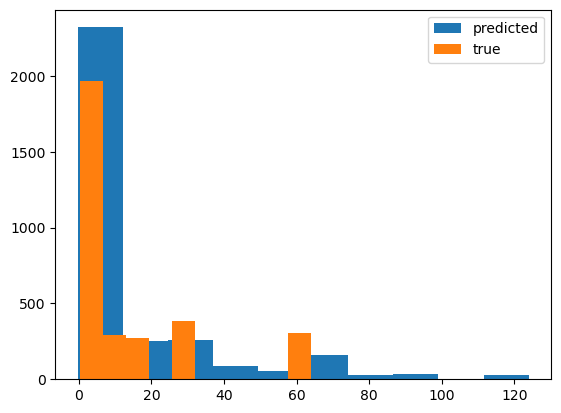

In [326]:
plt.hist(precitedm1, label ='predicted')
plt.hist(truem1, label ='true')
plt.legend()


In [286]:


def plot_4d_regression(model, X_train, y_train, X_test, y_test, train_mean, train_std,y_train_mean, y_train_std, 
                       feature_idx=(0, 1), fixed_values={}, labels=[] ):
    """
    Plots regression outputs for a PyTorch model using a 2D slice of a higher-dimensional space.
    Produces one panel per output dimension (color gradient).
    
    Parameters:
    - model: Trained PyTorch model.
    - X_train, y_train, X_test, y_test: datasets.
    - train_mean, train_std: normalization stats.
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: {feature_index: value} for fixing other dimensions.
    - labels: list of strings for axis and titles. Expected: [x_label, y_label, ..., etc].
    """

    # Step 1: Normalize fixed values
    fixed_values_norm = {k: (v - train_mean[k]) / train_std[k] for k, v in fixed_values.items()}

    
    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values_norm.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values_norm.items()])

    if (train_mask.sum() == 0 and test_mask.sum() == 0):
        return "No data points!"

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]

    # Step 2: Create meshgrid
    X_train_filtered_unnorm = np.array(X_train_filtered) * train_std + train_mean
    X_test_filtered_unnorm = np.array(X_test_filtered) * train_std + train_mean

    y_train_filtered_unnorm = np.array(y_train_filtered) * y_train_std + y_train_mean # [Mtot,f/Mtot,i, M1,f/Mtot,f]
    y_test_filtered_unnorm = np.array(y_test_filtered) * y_train_std + y_train_mean 

    # Correct Units 

    y_train_filtered_unnorm[:,0] = y_train_filtered_unnorm[:,0] * (X_train_filtered_unnorm[:,3] + X_train_filtered_unnorm[:,4])
    y_train_filtered_unnorm[:,1] *= y_train_filtered_unnorm[:,0]

    y_test_filtered_unnorm[:,0] = y_test_filtered_unnorm[:,0] * (X_test_filtered_unnorm[:,3] + X_test_filtered_unnorm[:,4])
    y_test_filtered_unnorm[:,1] *= y_test_filtered_unnorm[:,0]

    
    x_min, x_max = X_train_filtered_unnorm[:, feature_idx[0]].min() - 0.1, X_train_filtered_unnorm[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered_unnorm[:, feature_idx[1]].min() - 0.1, X_train_filtered_unnorm[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))

    # Normalize grid
    xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
    yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

    # Step 3: Build input space
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)
    
    for k, v in fixed_values_norm.items():
        X_vis[:, k] = v

    # Step 4: Model predictions
    X_vis = X_vis.to(device)
    model.eval()
    with torch.no_grad():
        preds = model(X_vis).detach().cpu().numpy()   # shape (Ngrid, 2)

    # Changing the training and testing data to be M1f and M2f 
        
    y_train_filtered_corrected = np.empty((len(y_train_filtered_unnorm[:,0]), 2))
    y_test_filtered_corrected = np.empty((len(y_test_filtered_unnorm[:,0]), 2))
    
    y_train_filtered_corrected[:,0] = y_train_filtered_unnorm[:, 1]
    y_train_filtered_corrected[:,1] = y_train_filtered_unnorm[:, 0] - y_train_filtered_unnorm[:, 1]

    y_test_filtered_corrected[:,0] = y_test_filtered_unnorm[:, 1]
    y_test_filtered_corrected[:,1] = y_test_filtered_unnorm[:, 0] - y_test_filtered_unnorm[:, 1]

    # Now put in terms of Mass 1 and Mass 2 Final 
    # M_tot_f = (preds[:, 0]  * y_train_std[0] ) + y_train_mean[0]    # model predicts total final mass
    # M1_f = (preds[:, 1]  * y_train_std[1] ) + y_train_mean[1]      # model predicts final M1
    # M2_f = M_tot_f - M1_f
    print(preds[:, 0], y_train_std[0], y_train_mean[0], fixed_values[3] + fixed_values[4])
    M_tot_f = (preds[:, 0]  * y_train_std[0] ) + y_train_mean[0]    # model predicts total final mass / total initial mass
    M_tot_f *= (fixed_values[3] + fixed_values[4])
    M1_f = (preds[:, 1]  * y_train_std[1] ) + y_train_mean[1]      # model predicts final M1 / total final mass
    M1_f *= M_tot_f
    M2_f = M_tot_f - M1_f
    print(M_tot_f)
    # Reshape into grid for each output dimension
    M1_f = M1_f.reshape(xx.shape)
    M2_f = M2_f.reshape(xx.shape)

    # Step 5: Plot two panels
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    vmin = min(y_train_filtered_corrected[:,0].min(), y_train_filtered_corrected[:,1].min(),
           y_test_filtered_corrected[:,0].min(), y_test_filtered_corrected[:,1].min(),
           M1_f.min(), M2_f.min())
    vmax = max(y_train_filtered_corrected[:,0].max(), y_train_filtered_corrected[:,1].max(),
           y_test_filtered_corrected[:,0].max(), y_test_filtered_corrected[:,1].max(),
           M1_f.max(), M2_f.max())
    # print(y_train_filtered_corrected[:,0].min(), y_train_filtered_corrected[:,1].min(),
    #        y_test_filtered_corrected[:,0].min(), y_test_filtered_corrected[:,1].min(),
    #        M1_f.min(), M2_f.min())
    # print(y_train_filtered_corrected[:,0].max(), y_train_filtered_corrected[:,1].max(),
    #        y_test_filtered_corrected[:,0].max(), y_test_filtered_corrected[:,1].max(),
    #        M1_f.max(), M2_f.max())
    
    # print(vmin,vmax)
    
    cmap = plt.cm.coolwarm
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i, (Z, ax, title) in enumerate(zip([M1_f, M2_f], axes, ['Star 1 Final Mass', 'Star 2 Final Mass'])):
        im = ax.contourf(xx, yy, Z, levels = 100, cmap=cmap, norm = norm)
        scatter1 = ax.scatter(X_train_filtered_unnorm[:, feature_idx[0]],
                              X_train_filtered_unnorm[:, feature_idx[1]],
                              c=y_train_filtered_corrected[:, i], cmap=cmap, norm = norm, edgecolor="k", marker="o", label="Train")
        scatter2 = ax.scatter(X_test_filtered_unnorm[:, feature_idx[0]],
                              X_test_filtered_unnorm[:, feature_idx[1]],
                              c=y_test_filtered_corrected[:, i], cmap=cmap, norm = norm, marker="^", label="Test")

        ax.set_xlabel(fr"{labels[0]}", fontsize=14)
        ax.set_ylabel(fr"{labels[1]}", fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.set_title(title, fontsize=15)
    
   
    # After plotting the contours and scatters
    plt.tight_layout(rect=[0,0,0.9,1])  # leave 10% space on the right for the colorbar

    # Create the colorbar on a dedicated axis outside the panels
    cbar_ax = fig.add_axes([0.9999, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                    cax=cbar_ax, orientation='vertical', shrink=0.8)
    cbar.set_label('Final Mass', fontsize=14)

    fig.suptitle(fr"$\mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot,\ \mathrm{{Time}} = {round(10**(float(labels[4])),3)}\ \mathrm{{Gyr}}$", fontsize = 17)

    plt.tight_layout()
    return fig




[0.38048795 0.3811699  0.38185218 ... 0.55855745 0.5585573  0.55855685] 0.30083820998112976 0.8384865939656981 8.0
[7.62361526 7.62525648 7.62689856 ... 8.05217614 8.05217571 8.05217471]


/var/folders/4h/5kpc_p3153q1gx8btc9x_3mc0000gn/T/ipykernel_99013/2731772206.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


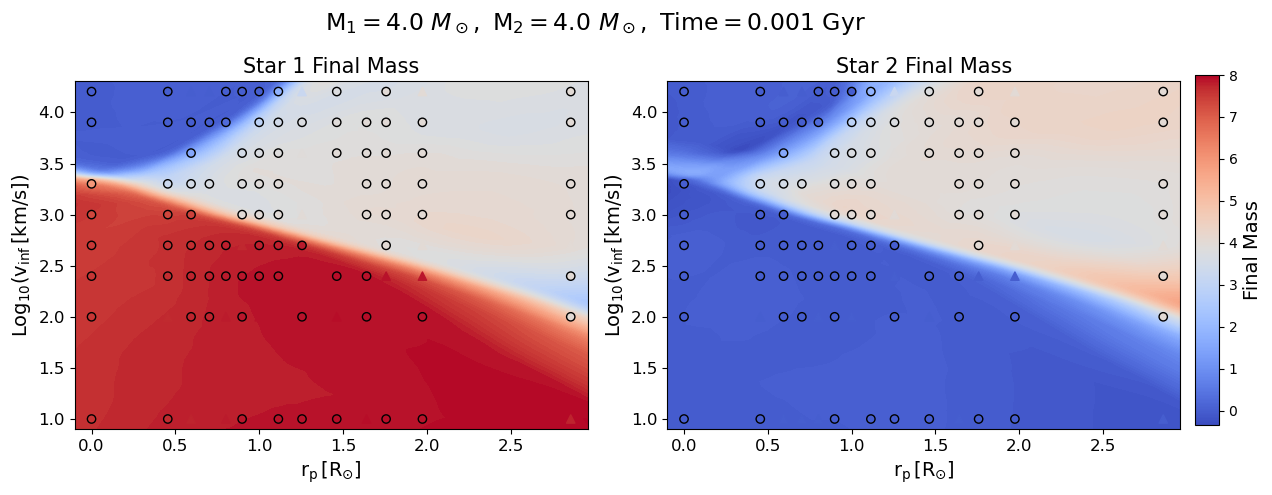

[0.3905817  0.39130715 0.39203265 ... 0.51541567 0.5156165  0.5158177 ] 0.30083820998112976 0.8384865939656981 12.0
[11.47186191 11.47448082 11.47709995 ... 11.92251985 11.92324478
 11.92397122]


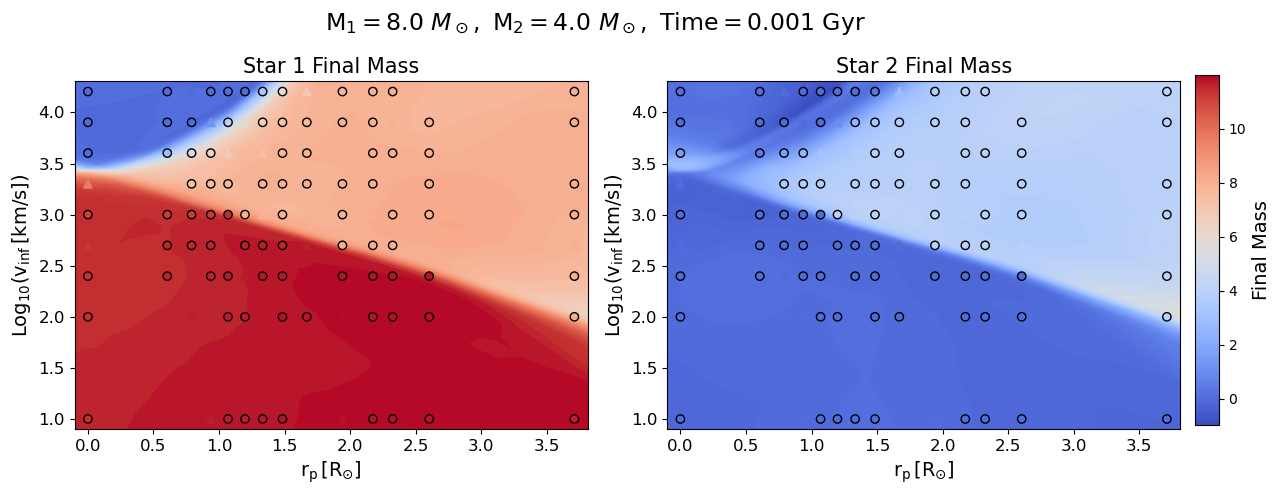

[0.35671148 0.3577291  0.3587672  ... 0.54317355 0.5430562  0.5429339 ] 0.30083820998112976 0.8384865939656981 16.0
[15.13278458 15.13768285 15.14267967 ... 16.03030325 16.02973834
 16.02914962]


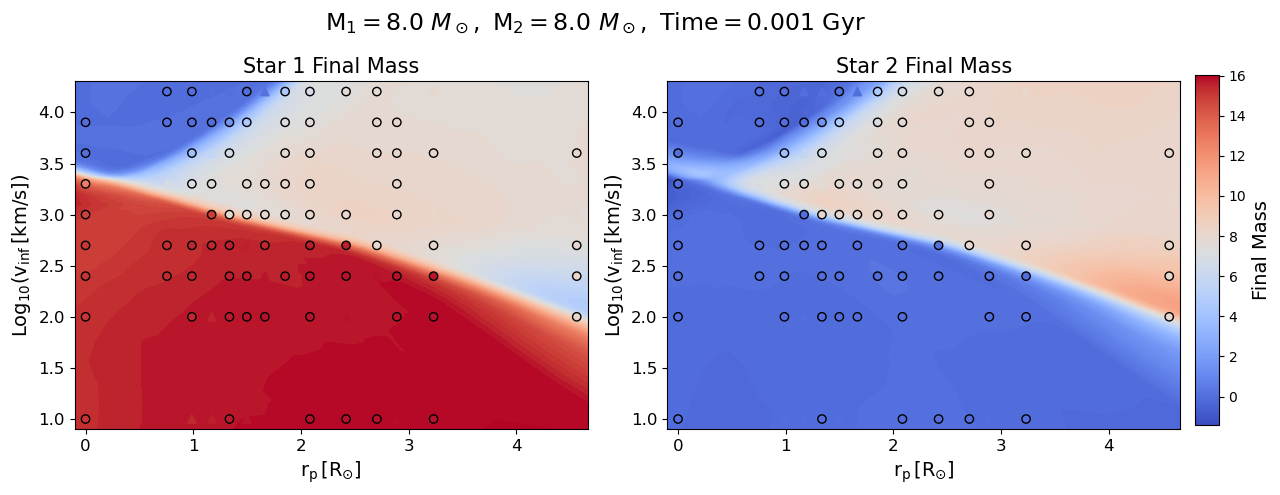

[0.4223658  0.42271778 0.42307952 ... 0.5925812  0.59290516 0.5932287 ] 0.30083820998112976 0.8384865939656981 20.0
[19.31100739 19.31312508 19.31530159 ... 20.3351533  20.33710244
 20.33904907]


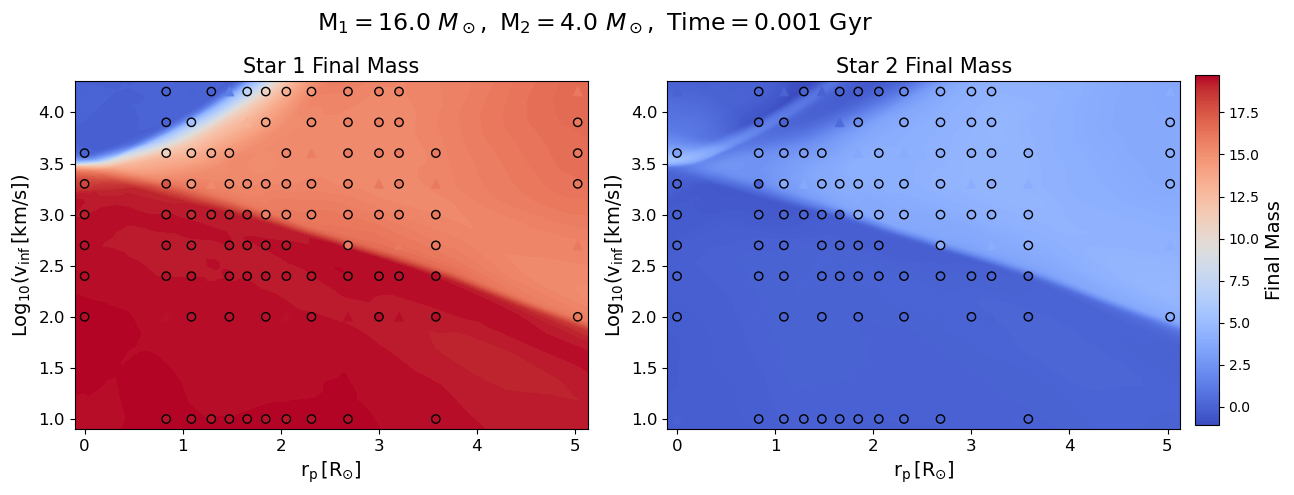

[0.38255414 0.38310713 0.38366127 ... 0.5928873  0.5929726  0.5930577 ] 0.30083820998112976 0.8384865939656981 24.0
[22.88576395 22.88975654 22.89375753 ... 24.40439383 24.40500966
 24.4056242 ]


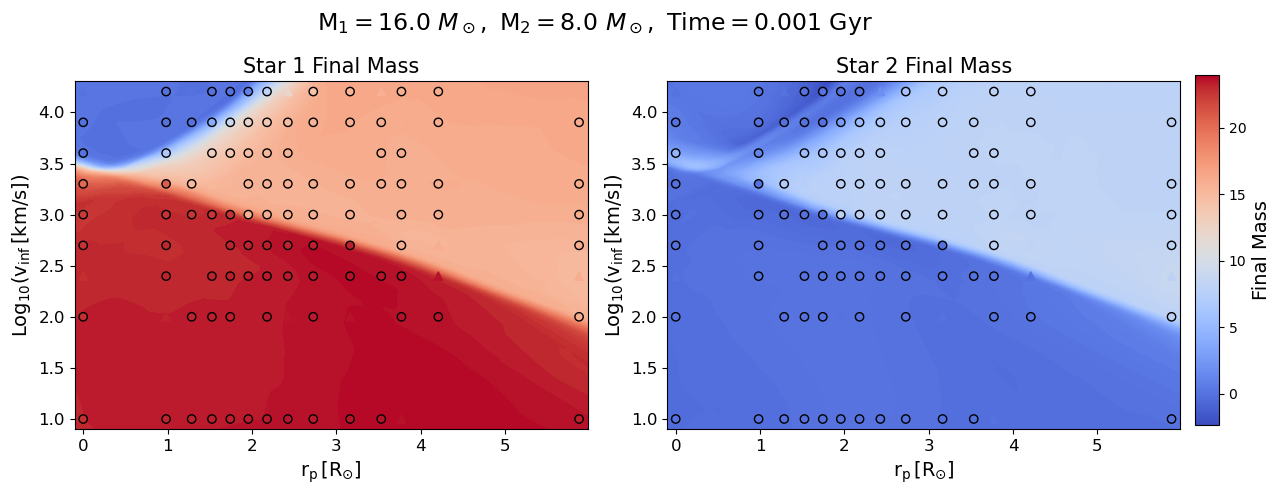

[0.34402528 0.34499475 0.34596506 ... 0.56222177 0.56209356 0.5619658 ] 0.30083820998112976 0.8384865939656981 32.0
[30.14344143 30.15277434 30.16211528 ... 32.24398027 32.24274602
 32.24151636]


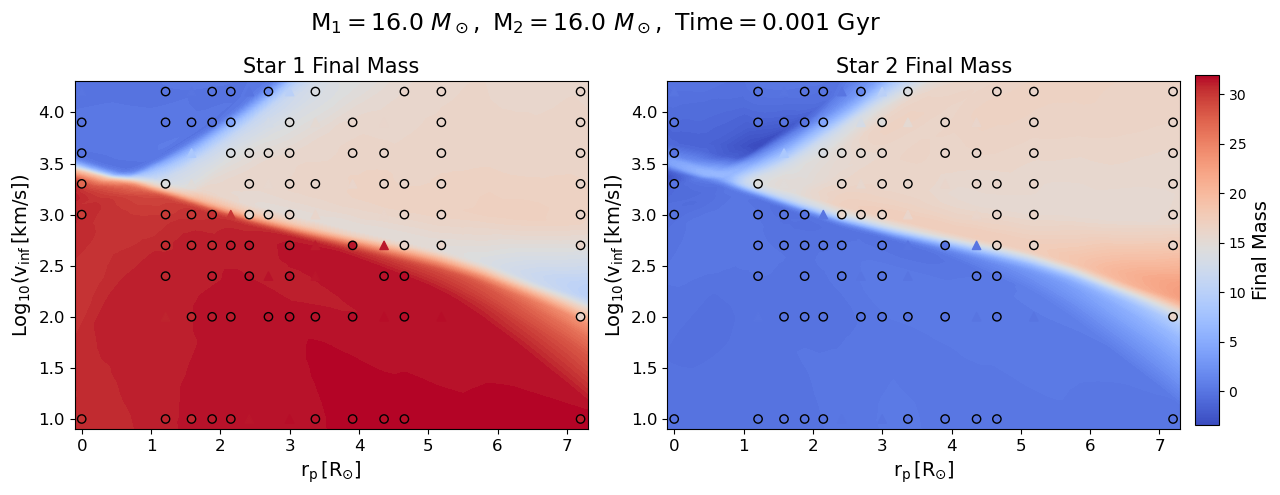

[0.52617556 0.5258361  0.5254504  ... 0.57559234 0.57542396 0.5752526 ] 0.30083820998112976 0.8384865939656981 36.0
[35.88409106 35.88041477 35.87623755 ... 36.41928347 36.41745985
 36.41560395]


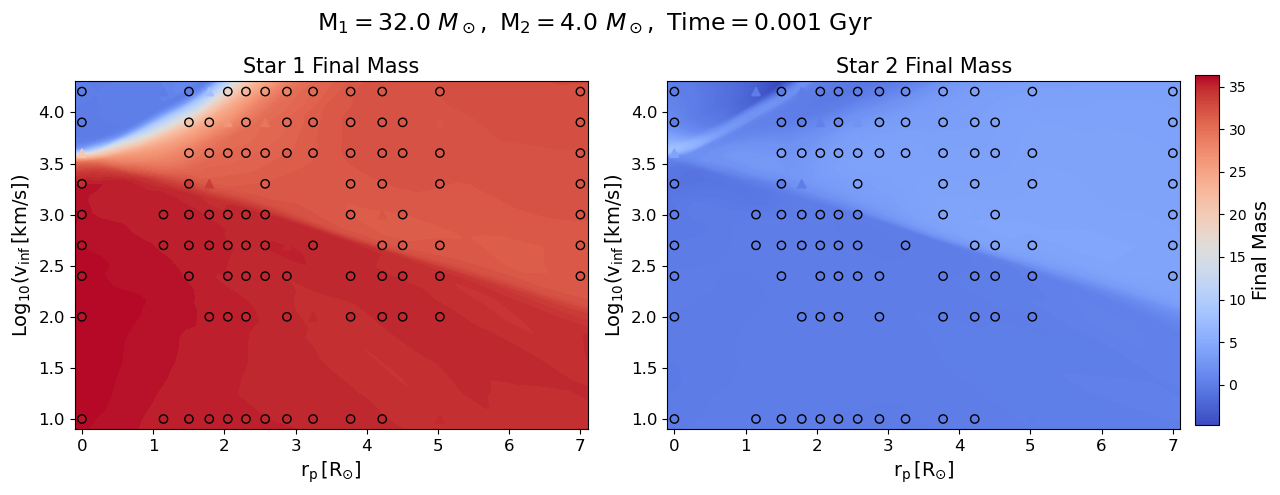

[0.4540646  0.45462096 0.4551833  ... 0.5215815  0.52156717 0.5215525 ] 0.30083820998112976 0.8384865939656981 40.0
[39.00346311 39.01015796 39.01692489 ... 39.8159292  39.81575706
 39.81558062]


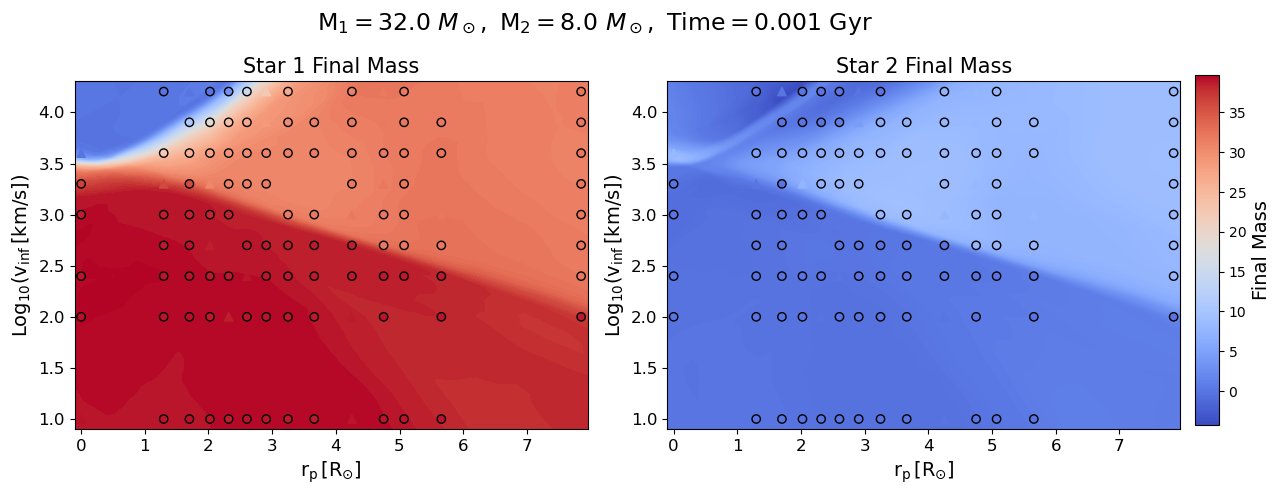

[0.37118748 0.37232795 0.37347135 ... 0.546536   0.5469086  0.54728144] 0.30083820998112976 0.8384865939656981 48.0
[45.60739058 45.62385931 45.64037022 ... 48.13946469 48.14484496
 48.15022867]


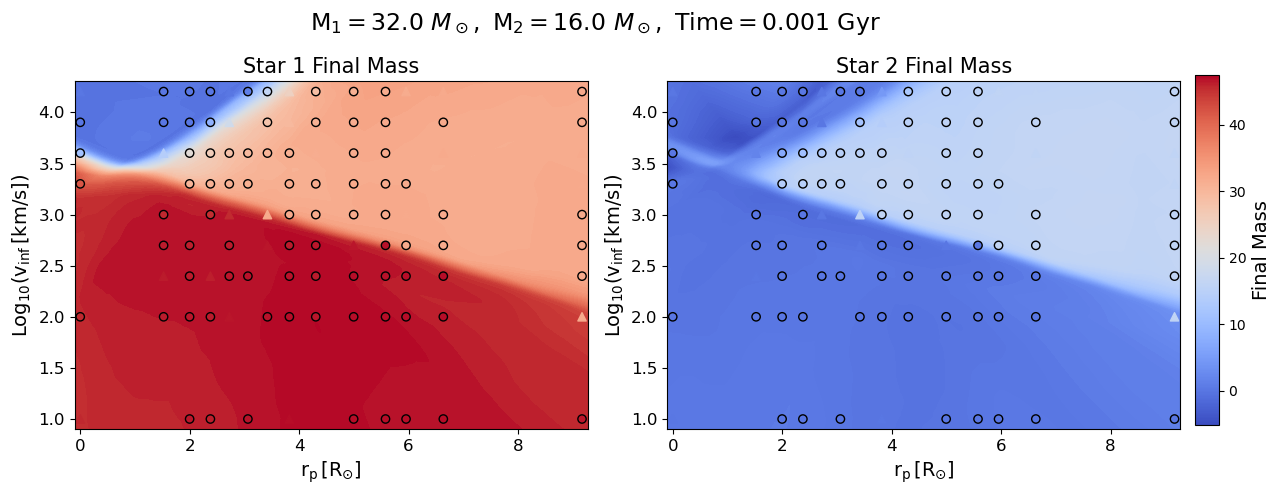

[0.3327323  0.33291242 0.3330923  ... 0.5700888  0.5702411  0.57039344] 0.30083820998112976 0.8384865939656981 64.0
[60.06945155 60.07291962 60.0763831  ... 64.63942971 64.64236185
 64.64529513]


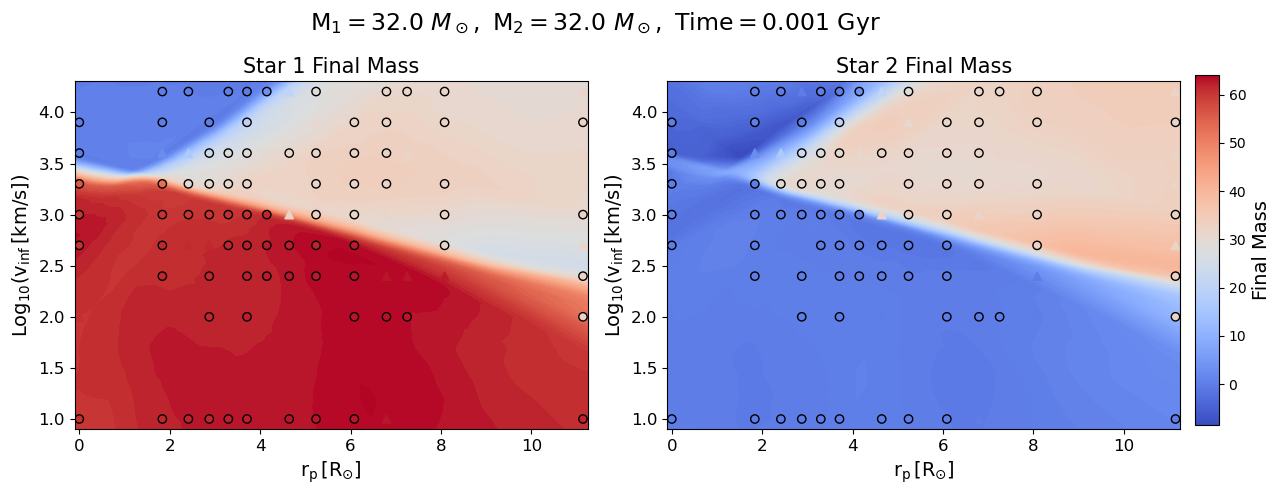

[0.5688986  0.5685335  0.5681485  ... 0.54228634 0.54231673 0.5423474 ] 0.30083820998112976 0.8384865939656981 68.0
[68.65504644 68.64757681 68.63970115 ... 68.11063904 68.1112609
 68.11188764]


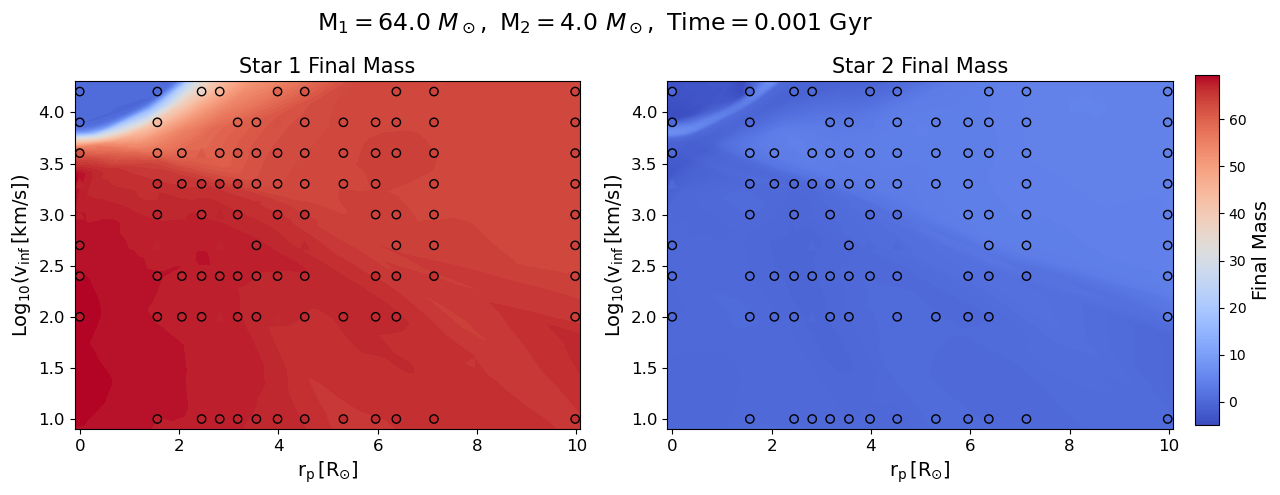

[0.49877515 0.49843982 0.4981319  ... 0.53868824 0.5388419  0.53923815] 0.30083820998112976 0.8384865939656981 72.0
[71.17467974 71.16741625 71.16074665 ... 72.03921124 72.04253959
 72.05112254]


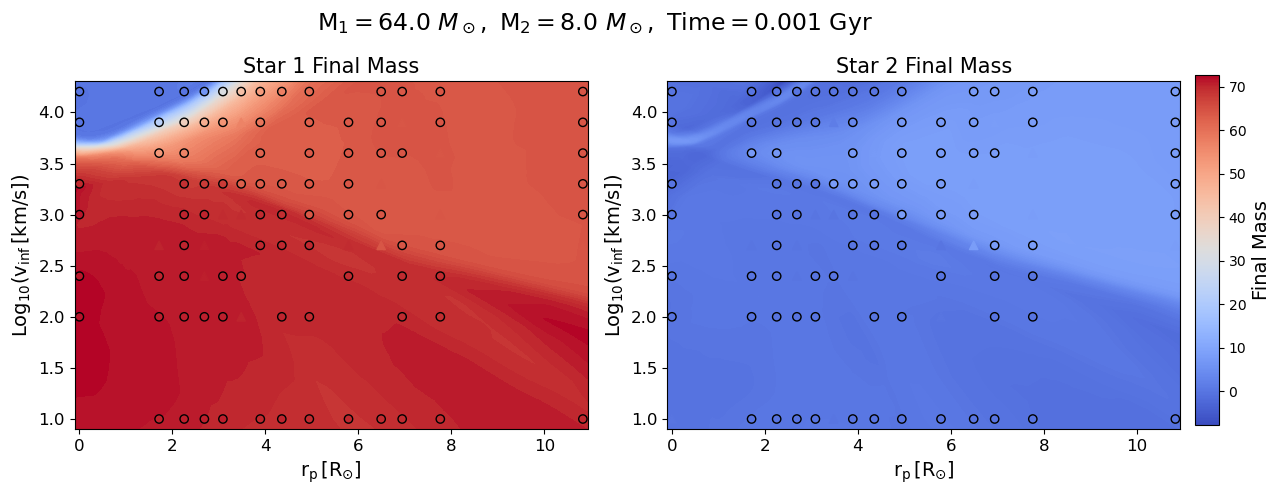

[0.42653617 0.42701074 0.42741132 ... 0.5118678  0.51197964 0.51209146] 0.30083820998112976 0.8384865939656981 80.0
[77.34439781 77.35581937 77.36545998 ... 79.39807944 79.40077058
 79.40346172]


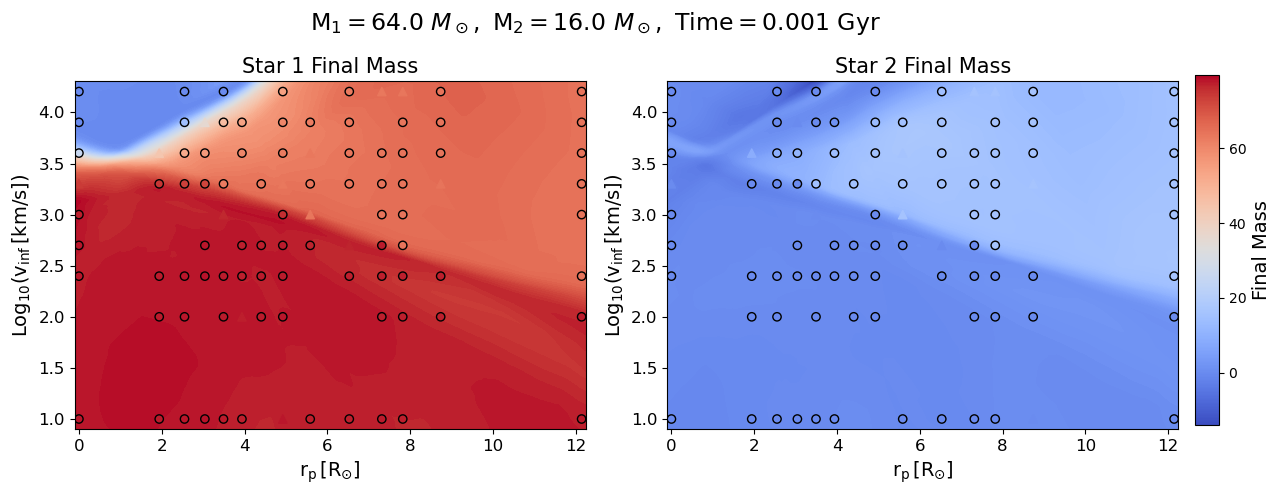

[0.36356673 0.36461174 0.36566868 ... 0.5730954  0.57366496 0.574237  ] 0.30083820998112976 0.8384865939656981 96.0
[90.99469029 91.02487091 91.05539581 ... 97.04597593 97.06242573
 97.0789461 ]


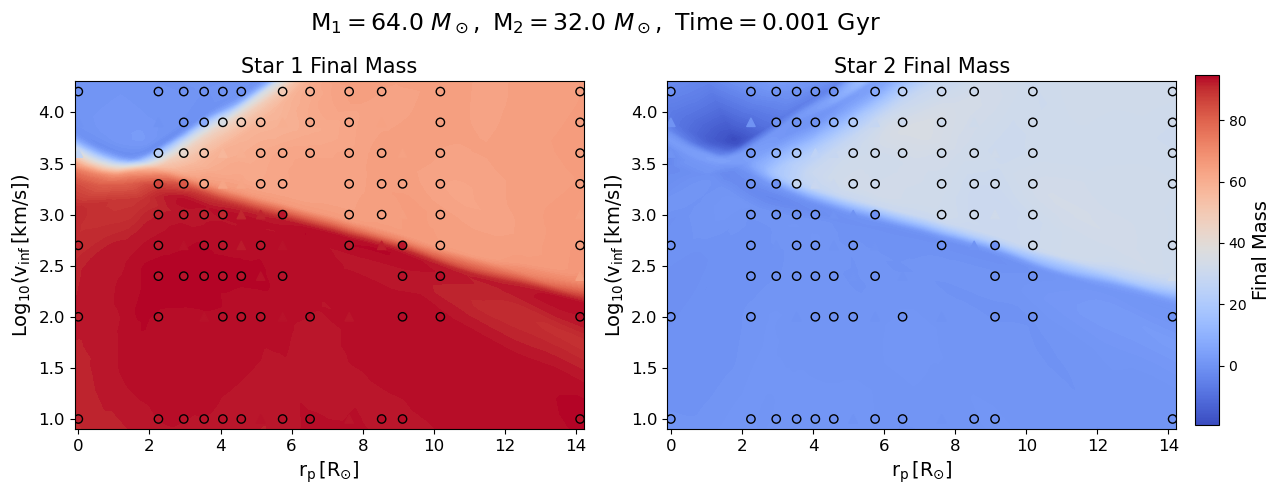

[0.34279945 0.34356007 0.34431306 ... 0.57120836 0.5707549  0.57027364] 0.30083820998112976 0.8384865939656981 128.0
[120.52656235 120.55585157 120.584847   ... 129.32197041 129.30450843
 129.28597688]


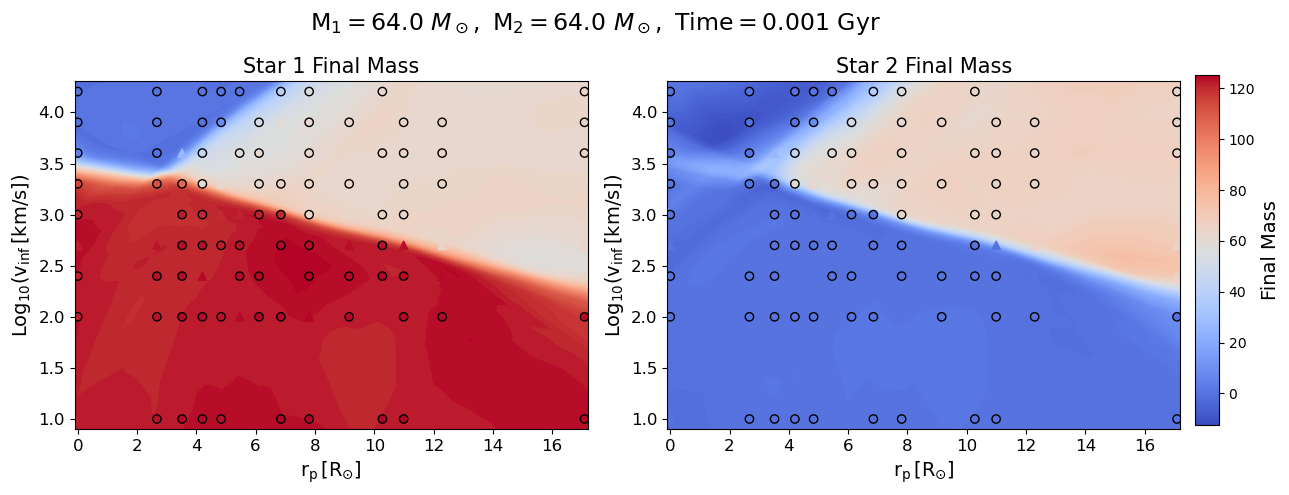

[0.38432023 0.38488838 0.38545612 ... 0.5889622  0.58905536 0.5891485 ] 0.30083820998112976 0.8384865939656981 4.0
[3.81641922 3.8171029  3.81778609 ... 4.06267571 4.06278782 4.06289992]


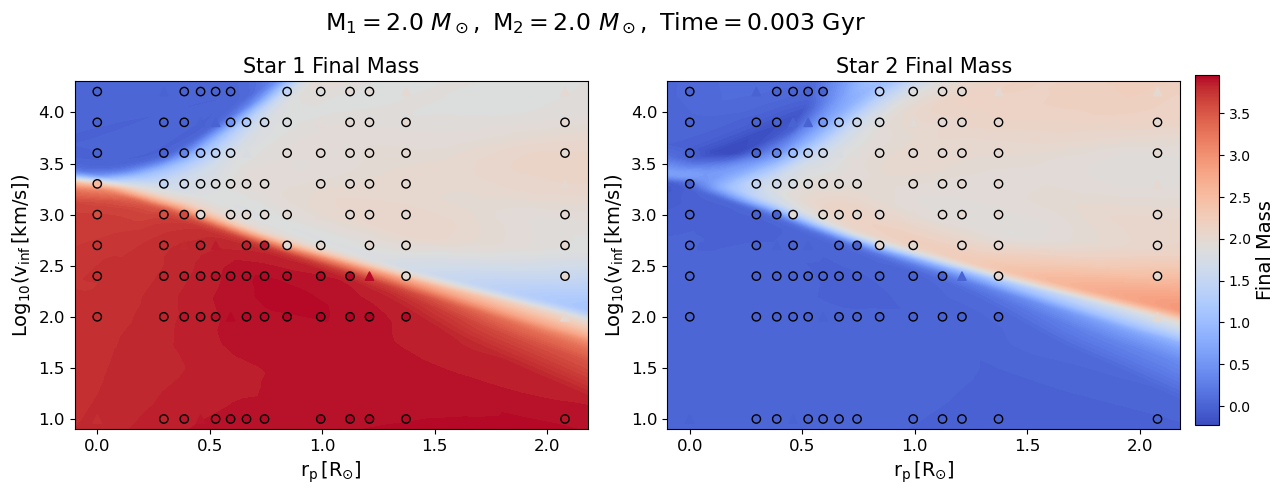

[0.4026244  0.40323576 0.40384984 ... 0.51975006 0.5198711  0.51999223] 0.30083820998112976 0.8384865939656981 6.0
[5.75766838 5.75877192 5.75988034 ... 5.96908363 5.96930214 5.96952076]


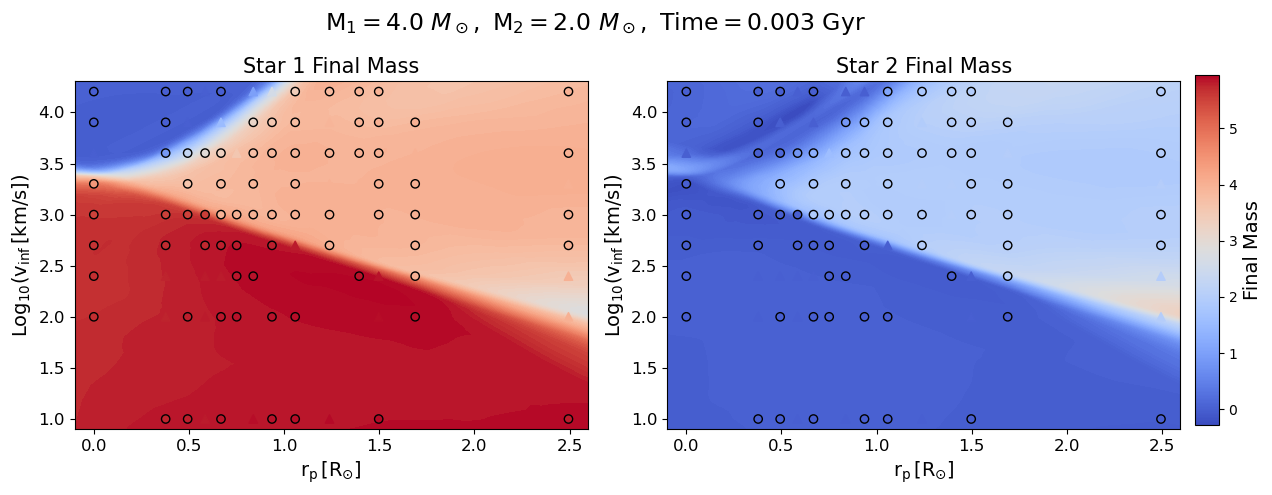

[0.36912867 0.36985317 0.3705707  ... 0.55536777 0.55542827 0.5554885 ] 0.30083820998112976 0.8384865939656981 8.0
[7.59627683 7.59802047 7.59974733 ... 8.04449951 8.04464512 8.04479014]


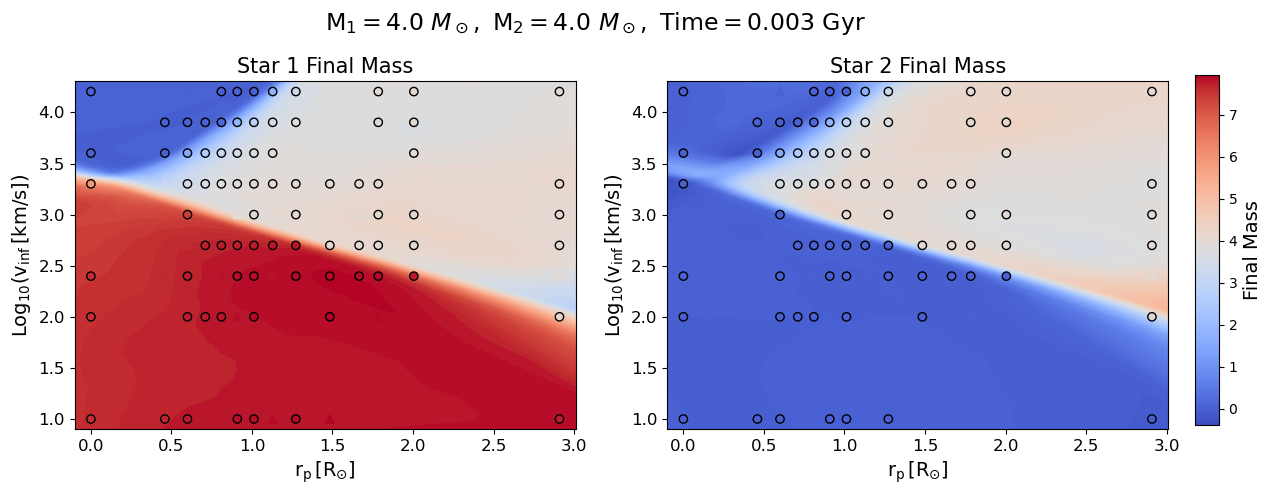

[0.41174874 0.41207692 0.41240558 ... 0.5223786  0.5224524  0.5225265 ] 0.30083820998112976 0.8384865939656981 10.0
[9.62356347 9.62455077 9.62553951 ... 9.95638044 9.95660243 9.95682532]


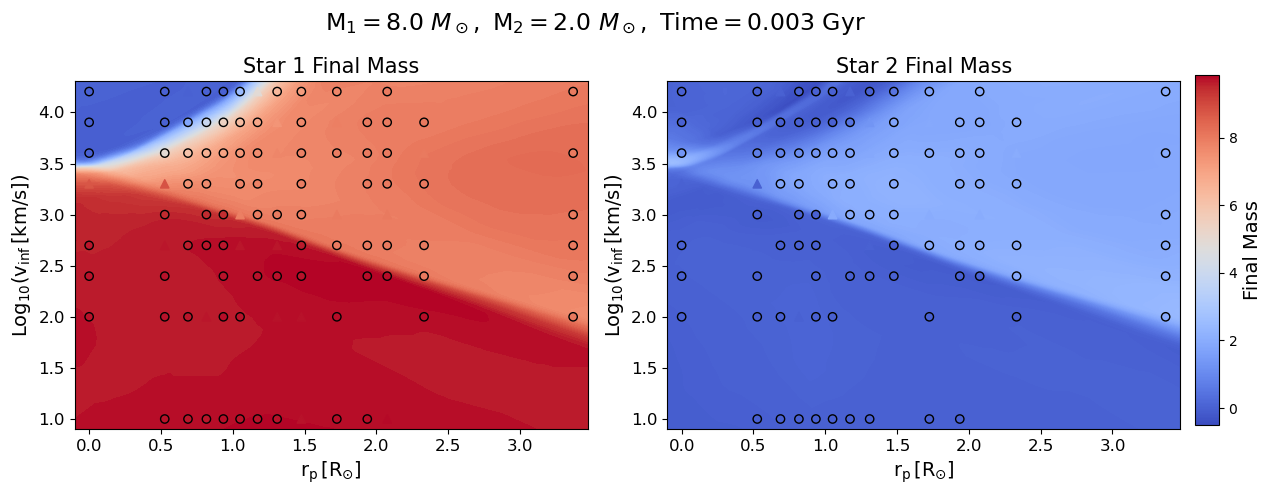

[0.38732567 0.38794896 0.3885705  ... 0.5144521  0.5147374  0.5150224 ] 0.30083820998112976 0.8384865939656981 12.0
[11.46010748 11.46235758 11.46460133 ... 11.91904131 11.92007136
 11.92110012]


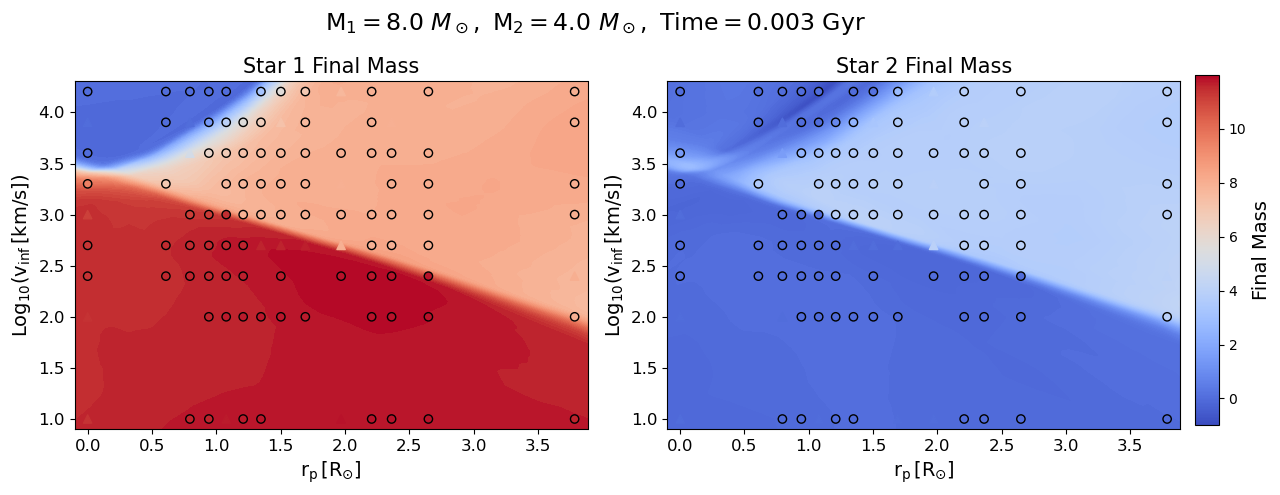

[0.34464315 0.3454801  0.34626302 ... 0.50809485 0.50834507 0.50863427] 0.30083820998112976 0.8384865939656981 16.0
[15.07469474 15.07872341 15.08249186 ... 15.86145501 15.86265943
 15.86405147]


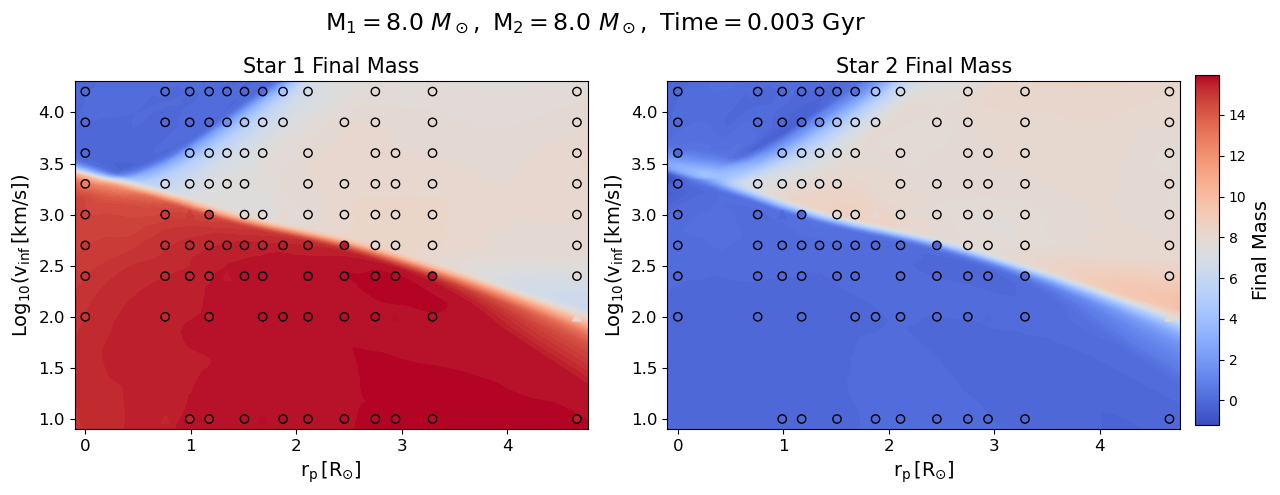

[0.463932   0.46387744 0.46380103 ... 0.5537545  0.55391175 0.55407095] 0.30083820998112976 0.8384865939656981 18.0
[17.60499124 17.60469575 17.60428196 ... 18.09138796 18.09223942
 18.09310152]


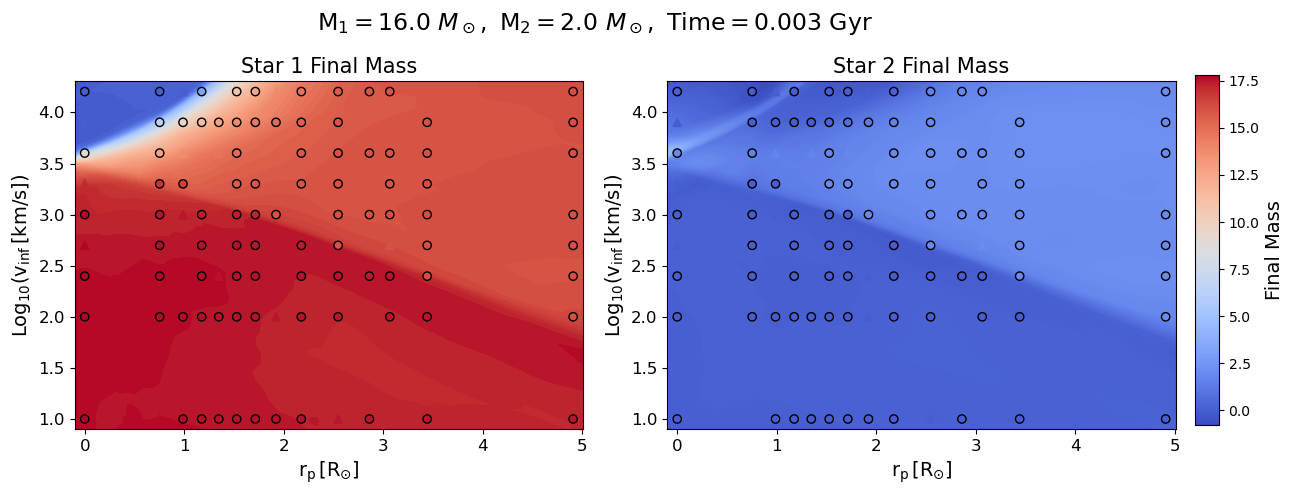

[0.41721305 0.4174449  0.4176778  ... 0.5730721  0.5732528  0.5734336 ] 0.30083820998112976 0.8384865939656981 20.0
[19.28000444 19.2813995  19.28280065 ... 20.21777143 20.21885879
 20.2199465 ]


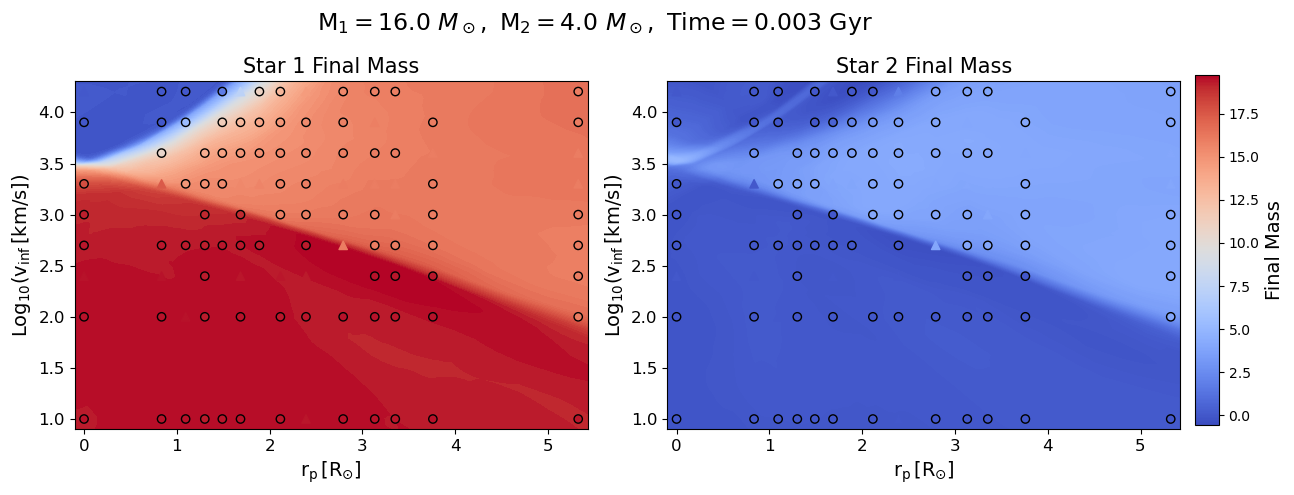

[0.3586888  0.35943568 0.36018673 ... 0.5488221  0.54892135 0.5490206 ] 0.30083820998112976 0.8384865939656981 24.0
[22.71345338 22.71884592 22.72426857 ... 24.08623809 24.08695462
 24.08767116]


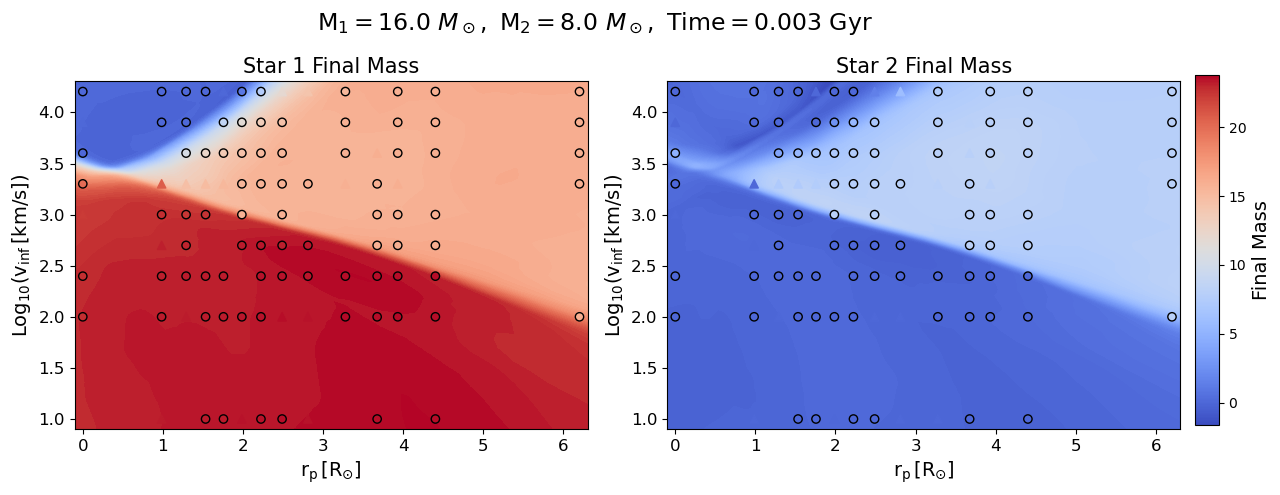

[0.3201737  0.32170966 0.32324514 ... 0.5308803  0.5313005  0.5317209 ] 0.30083820998112976 0.8384865939656981 32.0
[29.91382656 29.9286129  29.94339464 ... 31.94226127 31.94630659
 31.95035362]


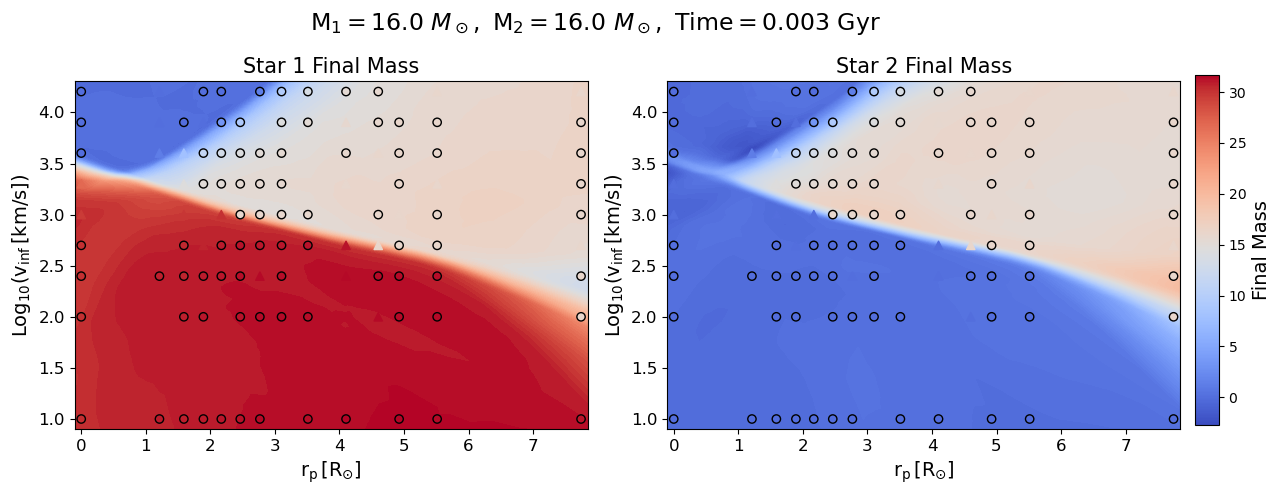

[0.52553463 0.52551776 0.52553636 ... 0.5283695  0.528437   0.5285046 ] 0.30083820998112976 0.8384865939656981 34.0
[33.8839747  33.88380217 33.88399238 ... 33.91297103 33.91366178
 33.91435314]


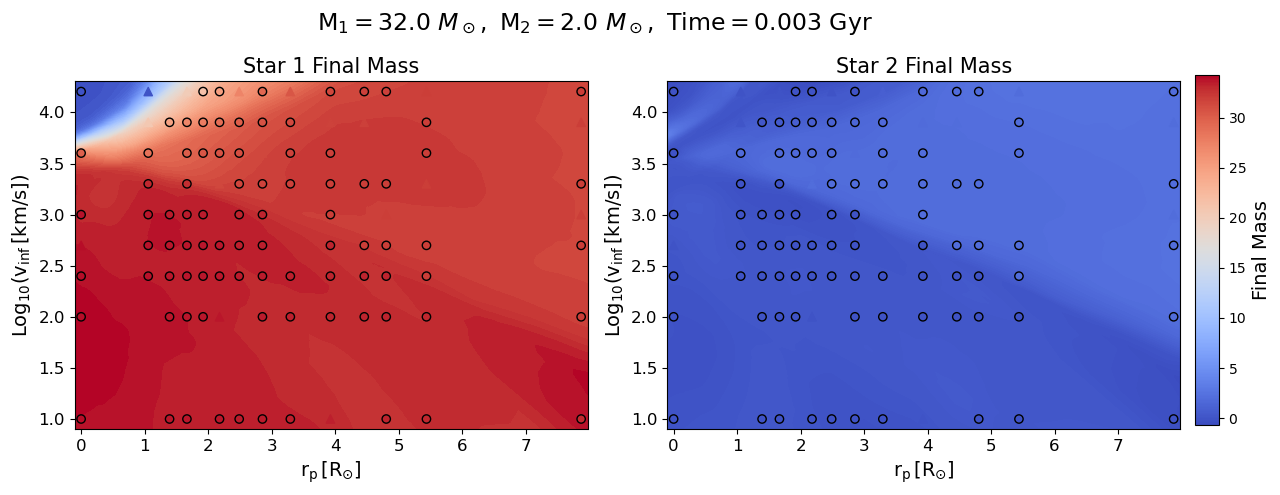

[0.4741393  0.47414085 0.47415593 ... 0.5403825  0.5403847  0.540387  ] 0.30083820998112976 0.8384865939656981 36.0
[35.32052927 35.32054606 35.32070938 ... 36.03795478 36.03797866
 36.03800319]


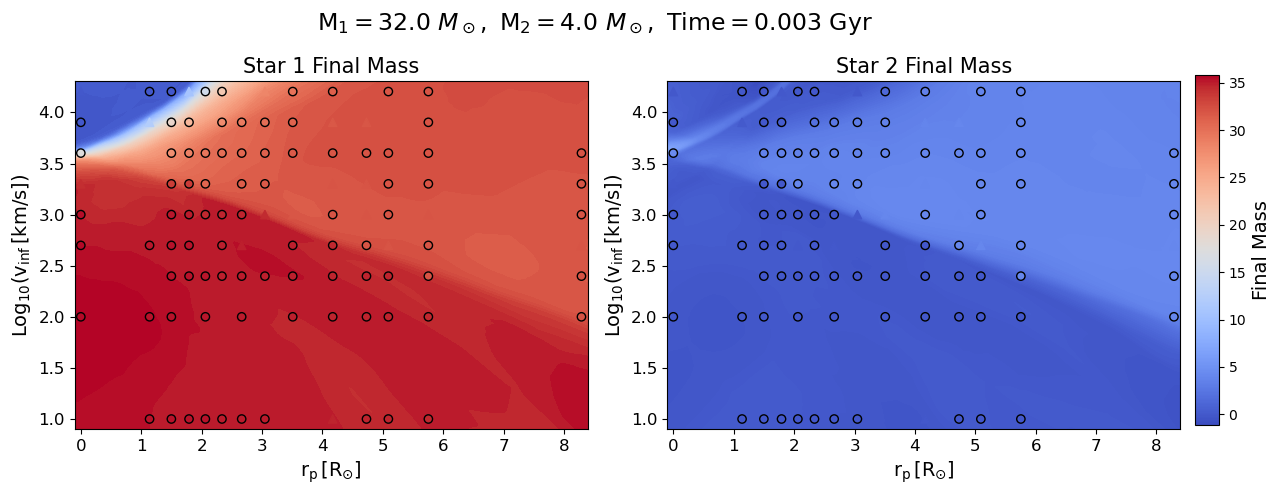

[0.4032275  0.40359938 0.40395623 ... 0.51744276 0.5174989  0.517555  ] 0.30083820998112976 0.8384865939656981 40.0
[38.39171343 38.39618838 38.40048258 ... 39.76612594 39.76680159
 39.76747653]


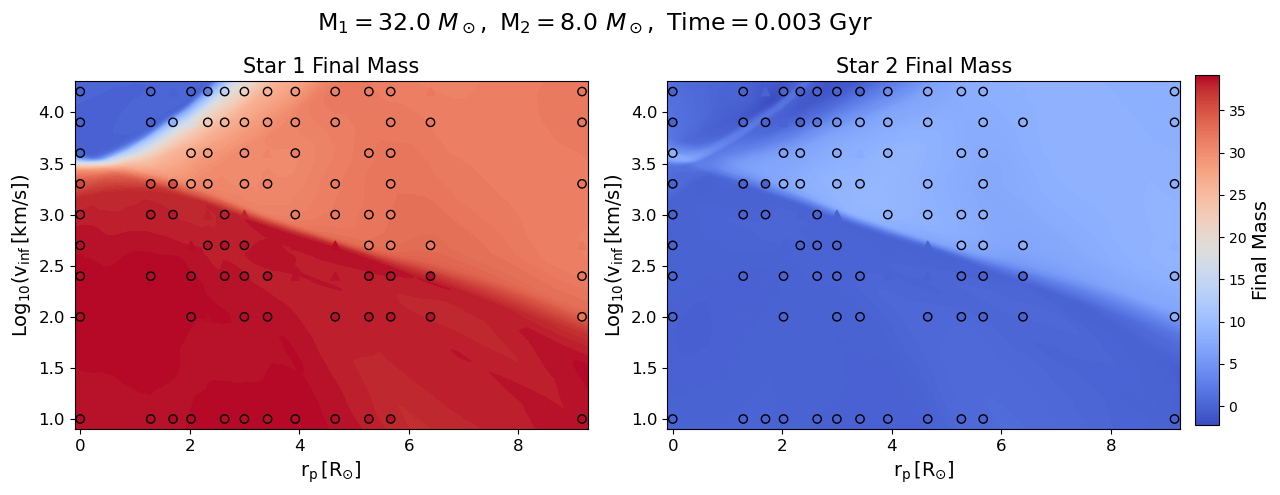

[0.32876846 0.33014908 0.3315486  ... 0.54829615 0.54836285 0.5484643 ] 0.30083820998112976 0.8384865939656981 48.0
[44.99485006 45.01478657 45.03499592 ... 48.16488131 48.16584444
 48.16730936]


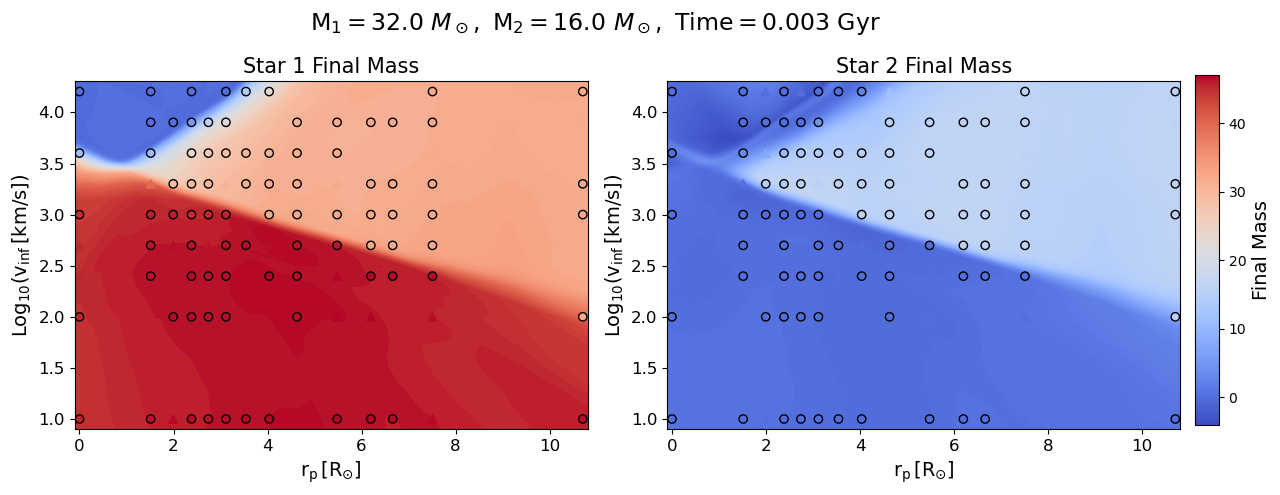

[0.30971482 0.3099015  0.3100882  ... 0.5485843  0.5489077  0.5492336 ] 0.30083820998112976 0.8384865939656981 64.0
[59.62628142 59.62987573 59.63347003 ... 64.22538928 64.23161619
 64.23789131]


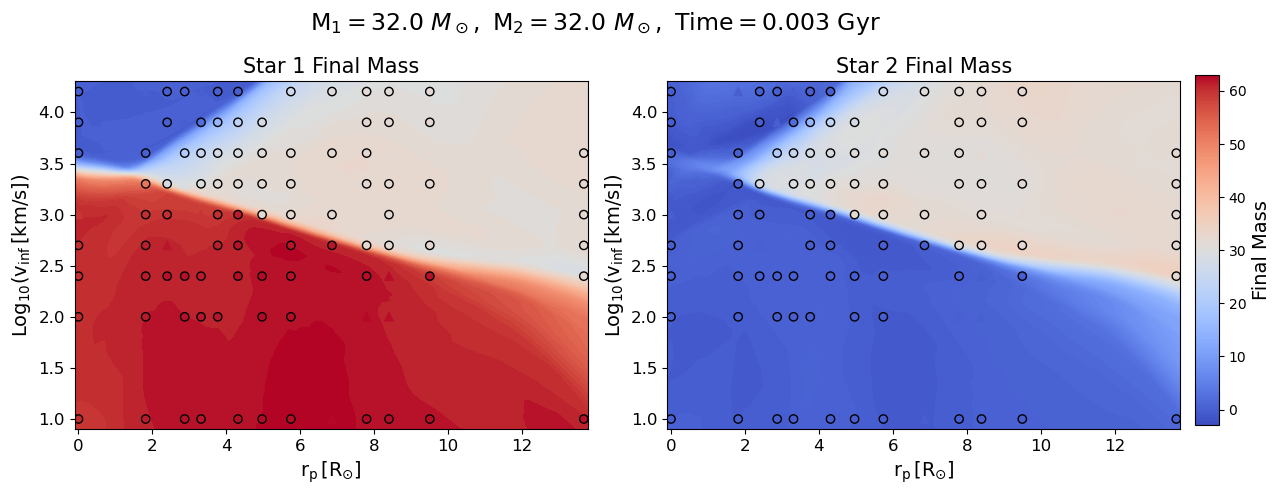

[0.57354635 0.57236105 0.5711744  ... 0.5382681  0.5382361  0.5382038 ] 0.30083820998112976 0.8384865939656981 66.0
[66.72806258 66.70452811 66.68096642 ... 66.02760136 66.02696584
 66.0263244 ]


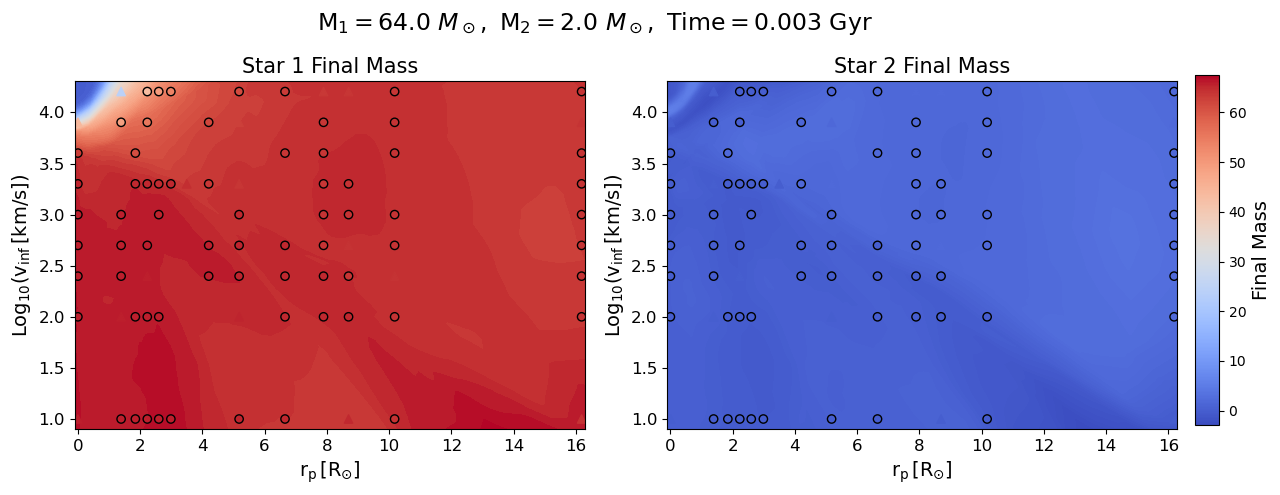

[0.49796328 0.49719825 0.49641708 ... 0.51265603 0.5127993  0.51294225] 0.30083820998112976 0.8384865939656981 68.0
[67.20392234 67.18827221 67.17229165 ... 67.50449198 67.50742325
 67.51034721]


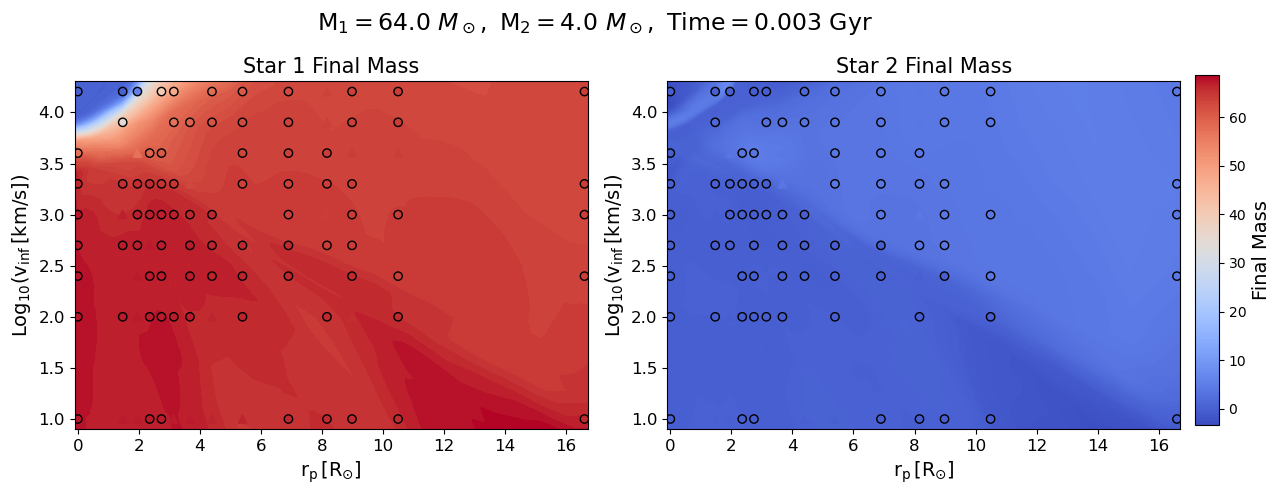

[0.42282876 0.42159703 0.42046902 ... 0.5402373  0.540299   0.5403607 ] 0.30083820998112976 0.8384865939656981 72.0
[69.52965425 69.50297455 69.47854128 ... 72.07276453 72.07410078
 72.07543702]


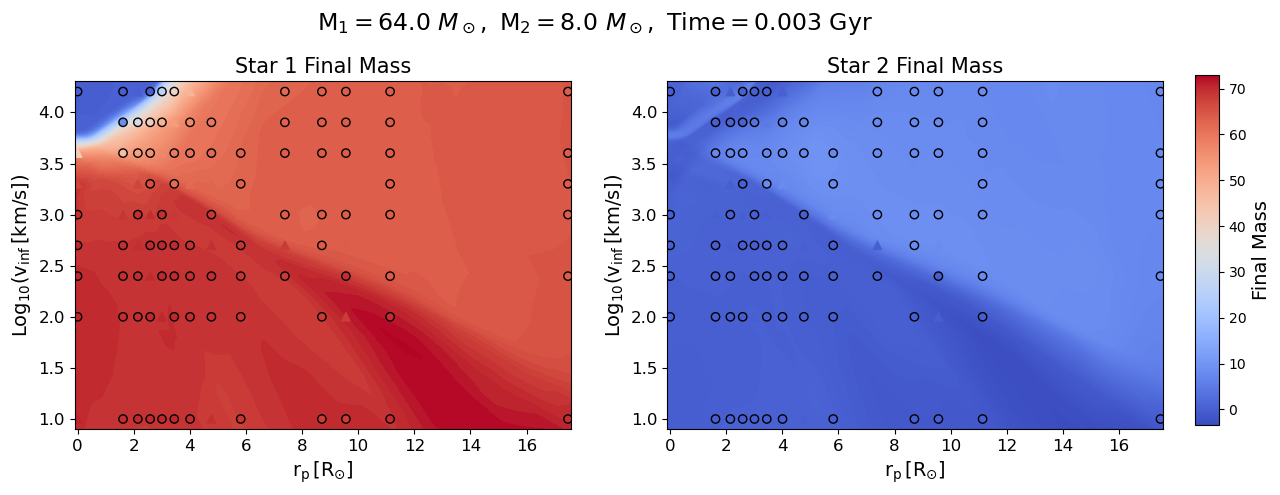

[0.34831777 0.34850278 0.34867314 ... 0.53578216 0.5354544  0.53512657] 0.30083820998112976 0.8384865939656981 80.0
[75.46191112 75.46636384 75.47046366 ... 79.97362715 79.96573879
 79.957849  ]


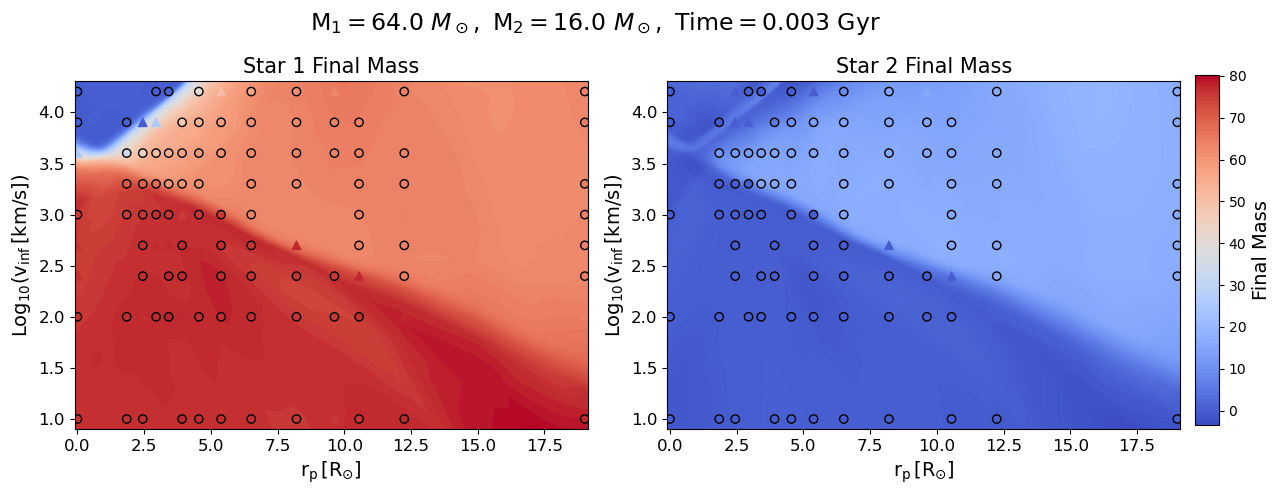

[0.29405725 0.2956204  0.29738447 ... 0.54784477 0.54798955 0.5481335 ] 0.30083820998112976 0.8384865939656981 96.0
[88.98722407 89.03236891 89.08331576 ... 96.31672639 96.32090769
 96.3250649 ]


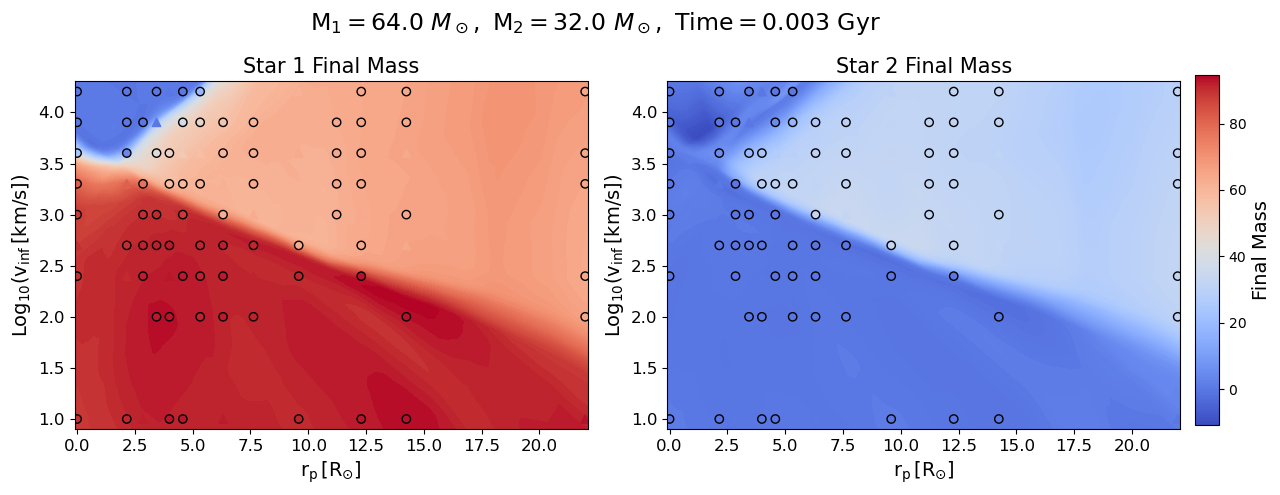

KeyboardInterrupt: 

In [331]:
# 0:Age[Gyr],1:Rp,2:Vinf[km/s]3:Mass1[MSUN],4:Mass2[Msun],
from matplotlib.backends.backend_pdf import PdfPages
unique_times = np.unique(x_data_og[:,0])
unique_mass = np.unique(x_data_og[:,4])
with PdfPages('decision_boundary_plots_22f_regression_final.pdf') as pdf:
    for time in unique_times:
        for mass1 in unique_mass:
            for mass2 in unique_mass:
                # print("Time: ", str(time) + " Mass1: " + str(mass1) + " Mass2: " + str(mass2) + '\n' )
                labels = [r'$\rm r_p \, [R_{\odot}]$', r'$\rm Log_{10}(v_{inf} \, [km/s])$', str(mass1), str(round(mass2,2)), str(time)]
                
                fig = plot_4d_regression(model, train_dataset.data, train_dataset.labels, test_dataset.data, test_dataset.labels, train_mean, train_std, y_train_mean, y_train_std, 
                       feature_idx=(1, 2), fixed_values={0: time, 3: mass1, 4: mass2}, labels = labels)
                if fig != "No data points!":
                    # Save the current figure to the PDF
                    pdf.savefig(fig , bbox_inches='tight')  # Saves the current figure
                    plt.show()
                    plt.close(fig )    # Close it to avoid overlap

In [135]:

y_train_filtered_corrected =  np.empty((len(y_train[:,0]), 2))
print(np.shape(y_train_filtered_corrected))
print(len(y_train[:,0]))

(15031, 2)
15031
